<a href="https://colab.research.google.com/github/rakibul-islam-shafin/Projectile_Motion_Simulator/blob/main/Copy_of_Projectile_Motion_Simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import math

# Gravity
g = 9.8

# Get information from the user
velocity = float(input("Enter initial velocity (m/s): "))
angle = float(input("Enter launch angle (degrees): "))

# Convert degrees to radians
angle_rad = math.radians(angle)

# Calculate flight time
flight_time = (2 * velocity * math.sin(angle_rad)) / g

# Calculate maximum height
max_height = (velocity ** 2 * math.sin(angle_rad) ** 2) / (2 * g)

# Calculate horizontal range
range_distance = (velocity ** 2 * math.sin(2 * angle_rad)) / g

# Show results
print("\n--- Projectile Motion Results ---")
print(f"Flight time: {flight_time:.2f} seconds")
print(f"Maximum height: {max_height:.2f} meters")
print(f"Range: {range_distance:.2f} meters")

Enter initial velocity (m/s): 20
Enter launch angle (degrees): 45

--- Projectile Motion Results ---
Flight time: 2.89 seconds
Maximum height: 10.20 meters
Range: 40.82 meters


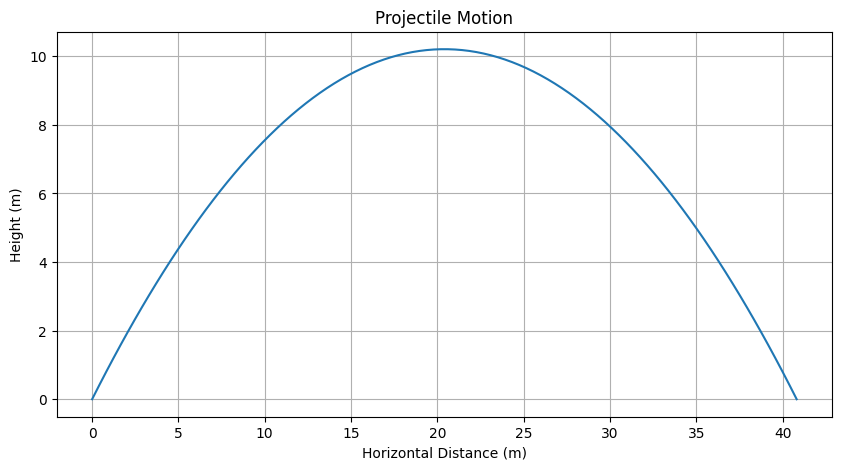

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create time values
time = np.linspace(0, flight_time, 100)

# Calculate horizontal and vertical positions
x = velocity * np.cos(angle_rad) * time
y = velocity * np.sin(angle_rad) * time - 0.5 * g * time**2

# Create the graph
plt.figure(figsize=(10, 5))

plt.plot(x, y)

plt.title("Projectile Motion")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Height (m)")

plt.grid(True)
plt.show()

/tmp/ipykernel_439/979727759.py:102: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  animation = FuncAnimation(
/tmp/ipykernel_439/979727759.py:114: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  HTML(animation.to_jshtml())


/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


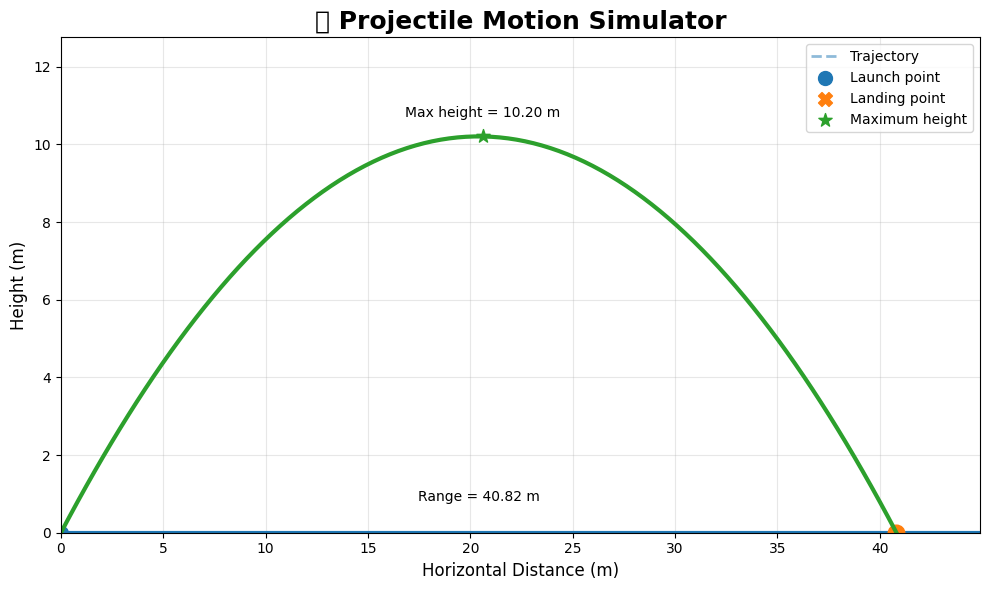

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Set graph limits
ax.set_xlim(0, range_distance * 1.1)
ax.set_ylim(0, max_height * 1.25)

# Title and labels
ax.set_title("🚀 Projectile Motion Simulator", fontsize=18, fontweight="bold")
ax.set_xlabel("Horizontal Distance (m)", fontsize=12)
ax.set_ylabel("Height (m)", fontsize=12)

# Grid
ax.grid(True, alpha=0.3)

# Ground
ax.axhline(y=0, linewidth=3)

# Full trajectory path
ax.plot(
    x,
    y,
    linestyle="--",
    linewidth=2,
    alpha=0.5,
    label="Trajectory"
)

# Launch point
ax.scatter(
    [0],
    [0],
    s=100,
    marker="o",
    label="Launch point"
)

# Landing point
ax.scatter(
    [range_distance],
    [0],
    s=100,
    marker="X",
    label="Landing point"
)

# Maximum height point
max_height_index = np.argmax(y)

ax.scatter(
    [x[max_height_index]],
    [y[max_height_index]],
    s=100,
    marker="*",
    label="Maximum height"
)

# Range line
ax.annotate(
    f"Range = {range_distance:.2f} m",
    xy=(range_distance / 2, 0),
    xytext=(range_distance / 2, max_height * 0.08),
    ha="center"
)

# Maximum height label
ax.annotate(
    f"Max height = {max_height:.2f} m",
    xy=(x[max_height_index], y[max_height_index]),
    xytext=(x[max_height_index], max_height * 1.05),
    ha="center"
)

# Animated projectile
ball, = ax.plot(
    [],
    [],
    marker="o",
    markersize=12,
    linestyle=""
)

# Animated trail
trail, = ax.plot(
    [],
    [],
    linewidth=3
)

# Animation function
def animate(i):
    ball.set_data([x[i]], [y[i]])
    trail.set_data(x[:i+1], y[:i+1])

    return ball, trail

# Create animation
animation = FuncAnimation(
    fig,
    animate,
    frames=len(x),
    interval=30,
    blit=True,
    repeat=True
)

ax.legend()
plt.tight_layout()

HTML(animation.to_jshtml())

In [ ]:
# Cell 4: Interactive Projectile Motion Simulator

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets

# Gravity
g = 9.8

# Create controls
velocity_slider = widgets.FloatSlider(
    value=20,
    min=5,
    max=50,
    step=1,
    description="Velocity:",
    continuous_update=False
)

angle_slider = widgets.IntSlider(
    value=45,
    min=10,
    max=80,
    step=1,
    description="Angle:",
    continuous_update=False
)

run_button = widgets.Button(
    description="🚀 Simulate",
    button_style="success"
)

output = widgets.Output()

def run_simulation(button):
    with output:
        clear_output(wait=True)

        # Get slider values
        velocity = velocity_slider.value
        angle = angle_slider.value

        # Convert angle to radians
        angle_rad = np.radians(angle)

        # Physics calculations
        flight_time = (2 * velocity * np.sin(angle_rad)) / g
        max_height = (velocity**2 * np.sin(angle_rad)**2) / (2 * g)
        range_distance = (velocity**2 * np.sin(2 * angle_rad)) / g

        # Time values
        time = np.linspace(0, flight_time, 200)

        # Projectile position
        x = velocity * np.cos(angle_rad) * time
        y = velocity * np.sin(angle_rad) * time - 0.5 * g * time**2

        # Display results
        print("🚀 PROJECTILE MOTION RESULTS")
        print("--------------------------------")
        print(f"Initial velocity : {velocity:.1f} m/s")
        print(f"Launch angle     : {angle}°")
        print(f"Flight time      : {flight_time:.2f} seconds")
        print(f"Maximum height   : {max_height:.2f} meters")
        print(f"Range            : {range_distance:.2f} meters")

        # Create graph
        plt.figure(figsize=(10, 6))

        plt.plot(x, y, linewidth=3, label="Projectile path")

        # Ground
        plt.axhline(0, linewidth=2)

        # Launch point
        plt.scatter(0, 0, s=100, marker="o", label="Launch")

        # Maximum height
        max_index = np.argmax(y)
        plt.scatter(
            x[max_index],
            y[max_index],
            s=150,
            marker="*",
            label="Maximum height"
        )

        # Landing point
        plt.scatter(
            range_distance,
            0,
            s=100,
            marker="X",
            label="Landing"
        )

        # Labels
        plt.annotate(
            f"Max height: {max_height:.2f} m",
            (x[max_index], y[max_index]),
            xytext=(10, 10),
            textcoords="offset points"
        )

        plt.annotate(
            f"Range: {range_distance:.2f} m",
            (range_distance, 0),
            xytext=(-80, 15),
            textcoords="offset points"
        )

        plt.title("🚀 Interactive Projectile Motion Simulator", fontsize=16)
        plt.xlabel("Horizontal Distance (m)")
        plt.ylabel("Height (m)")
        plt.grid(True, alpha=0.3)
        plt.legend()

        plt.xlim(0, range_distance * 1.1)
        plt.ylim(0, max_height * 1.25)

        plt.show()


# Connect button to simulation
run_button.on_click(run_simulation)

# Show controls
display(velocity_slider)
display(angle_slider)
display(run_button)
display(output)

FloatSlider(value=20.0, continuous_update=False, description='Velocity:', max=50.0, min=5.0, step=1.0)

IntSlider(value=45, continuous_update=False, description='Angle:', max=80, min=10)

Button(button_style='success', description='🚀 Simulate', style=ButtonStyle())

Output()

# 🚀 Projectile Motion Simulator

A Python-based interactive simulator that demonstrates the motion of a projectile using basic physics equations.

## 📌 Project Overview

This project allows users to change the initial velocity and launch angle and observe how these values affect projectile motion.

The simulator calculates:

- ⏱️ Flight time
- 📏 Horizontal range
- ⬆️ Maximum height
- 📈 Projectile trajectory

## 🎛️ Interactive Features

- Change initial velocity using a slider
- Change launch angle using a slider
- Run the simulation with one button
- View the projectile trajectory
- See calculated physics results

## 🧮 Physics Concepts

The project uses basic projectile-motion equations and assumes ideal conditions where air resistance is ignored.

## 🛠️ Technologies Used

- Python
- NumPy
- Matplotlib
- Google Colab
- Jupyter Widgets

## 📚 What I Learned

Through this project, I practiced:

- Python programming
- Mathematical calculations
- Physics equations
- NumPy
- Data visualization
- Interactive Python applications
- GitHub project management

## 🚀 Future Improvements

Possible future improvements include:

- Air resistance
- Wind effects
- Different launch and landing heights
- 3D projectile motion
- More interactive controls

## 👨‍💻 Author

Created as a personal learning project while studying Python, Physics, and Computer Science.